In [26]:
import pandas as pd

file_path = "results.csv"

results = pd.read_csv(file_path)
results

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
0,train,AutoSklearn,breast-w,NaN,65.920298,0.998384,0.990909,0.991514,0.062397,0.413152
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
2,train,AutoSklearn,eucalyptus,NaN,56.530461,0.954334,0.825714,0.789756,0.665422,3.786953
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
4,train,AutoSklearn,wdbc,NaN,54.669093,0.996147,0.988827,0.986607,0.075828,0.423970
...,...,...,...,...,...,...,...,...,...,...
235,test,LightGBM,semeion,460.67,182.910000,0.996593,0.947699,0.946768,0.253646,74.120000
236,train,LightGBM,MiceProtein,448.35,178.070000,0.999489,0.978842,0.975627,0.078542,69.510000
237,test,LightGBM,MiceProtein,448.35,178.070000,0.999813,0.984568,0.984223,0.048023,69.510000
238,train,LightGBM,cmc,63.03,26.310000,0.708586,0.550915,0.513471,0.971305,13.950000


In [27]:
train_results = results[results["split"] == "train"]
train_results.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
0,train,AutoSklearn,breast-w,NaN,65.920298,0.998384,0.990909,0.991514,0.062397,0.413152
2,train,AutoSklearn,eucalyptus,NaN,56.530461,0.954334,0.825714,0.789756,0.665422,3.786953
4,train,AutoSklearn,wdbc,NaN,54.669093,0.996147,0.988827,0.986607,0.075828,0.423970
6,train,AutoSklearn,pc4,NaN,115.232249,0.990809,0.969499,0.890082,0.224395,5.328887
8,train,AutoSklearn,credit-g,NaN,294.931927,0.925386,0.853968,0.727698,0.598647,0.519495


In [28]:
test_results = results[results["split"] == "test"]
test_results.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
5,test,AutoSklearn,wdbc,NaN,54.669093,0.998089,0.988304,0.983999,0.079230,0.406010
7,test,AutoSklearn,pc4,NaN,115.232249,0.927329,0.897260,0.577596,0.310648,3.910934
9,test,AutoSklearn,credit-g,NaN,294.931927,0.772701,0.733333,0.488094,0.627840,0.322403


# statistics for train datasets

Estamos testando:
- H₀ (hipótese nula): todos os modelos têm desempenho equivalente.
    - Ou seja: as diferenças nos ranks médios são apenas devido ao acaso.

- H₁ (hipótese alternativa): pelo menos um modelo tem desempenho sistematicamente diferente.

In [87]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, rankdata
from math import sqrt
from itertools import combinations
from scipy.stats import norm

df_avg = train_results.groupby(["dataset", "nome_modelo"])["g_mean"].mean().reset_index()

table = df_avg.pivot(index="dataset", columns="nome_modelo", values="g_mean")
table = table.dropna()

models = list(table.columns)
datasets = list(table.index)
k = len(models)
N = len(datasets)

print(f"Comparando {k} modelos e {N} datasets")

Comparando 4 modelos e 30 datasets


In [88]:
# 2. CALCULAR RANKS POR DATASET

ranks = table.rank(axis=1, ascending=False)  # maior g-mean = melhor rank (1)
avg_ranks = ranks.mean()

print("\n===== Average Ranks =====")
print(avg_ranks)


===== Average Ranks =====
nome_modelo
AutoGulon      3.916667
AutoSklearn    1.416667
LightGBM       2.700000
t2g-former     1.966667
dtype: float64


O que foi feito: 

- Ordenado os modelos pela métrica G-Mean
- O melhor modelo no dataset recebe rank 1, o segundo melhor rank 2, e assim por diante
- Depois, é calculada a média desses ranks de cada modelo ao longo de todos os datasets.

Ou seja, os número exibidos são as médias dos ranks.

**Detalhe**:
Quanto MENOR o rank médio, melhor o modelo.
- Rank médio 1.0 → o modelo foi sempre o melhor em todos os datasets.
- Rank médio perto de k → o modelo foi quase sempre o pior.

Interpretando os seus resultados:

1. AutoSklearn – 1.35
    - Em média, ficou entre 1o e 2o lugar nos datasets.
    - É o melhor modelo globalmente, segundo o critério de G-Mean.

2. t2g-former – 2.07
    - Fica em média perto de 2o lugar.
    - Costuma performar bem, geralmente logo atrás do AutoSklearn.

3. LightGBM – 2.67
    - Em média entre 2o e 3o lugar.
    - Desempenho intermediário.

4. AutoGluon – 3.91
    - Quase k, ou seja, em muitos datasets ele foi o pior dos quatro.

In [89]:
# 3. FRIEDMAN TEST

stats = [ranks[col].values for col in models]
friedman_stat, friedman_p = friedmanchisquare(*stats)

print("\n===== Friedman Test =====")
print(f"Statistic: {friedman_stat:.4f}")
print(f"P-value: {friedman_p:.4f}")


===== Friedman Test =====
Statistic: 63.7273
P-value: 0.0000


Esse valor do Friedman mede quão diferentes os ranks são.

Para 4 modelos (k = 4), valores abaixo de ~8–9 tenderiam a não rejeitar H₀.

Mas 57.47 é gigante, ou seja:
- Os modelos têm ranks extremamente diferentes entre si.

Sobre o p-value:
- O p-value NÃO é exatamente zero, mas é um número muito pequeno e o Python arredondou para 0.
- Isso significa que as chances das diferenças observadas serem aleatórias são praticamente nulas.

Interpretação dos resultados:
- p-value pequeno (< 0.000001)
- Valor estatístico alto (57.47)
- Então:
    - REJEITA a hipótese nula.
    - Portanto:
        - Os classificadores NÃO têm desempenho equivalente. Existem diferenças estatisticamente significativas entre eles.

In [32]:
# 4. NEMENYI POST-HOC

q_alpha = 2.569   # para k=4 e alfa=0.05 (Tabela 5a)
CD = q_alpha * sqrt(k*(k+1)/(6*30))

print("Nemenyi Critical Difference")
print(f"CD = {CD:.4f}")

nemenyi_results = {}

for m1, m2 in combinations(models, 2):
    diff = abs(avg_ranks[m1] - avg_ranks[m2])
    nemenyi_results[(m1, m2)] = diff > CD

print("Nemenyi Significant Pairs (p<0.05)")

for (m1, m2), sig in nemenyi_results.items():
    if sig:
        print(f"{m1} vs {m2} → SIGNIFICANTE")



===== Nemenyi Critical Difference =====
CD = 0.8563

===== Nemenyi Significant Pairs (p<0.05) =====
AutoGulon vs AutoSklearn → SIGNIFICANTE
AutoGulon vs LightGBM → SIGNIFICANTE
AutoGulon vs t2g-former → SIGNIFICANTE
AutoSklearn vs LightGBM → SIGNIFICANTE


O Critical Difference é o quanto dois ranks médios precisam diferir para que a diferença seja considerada estatisticamente significativa (p < 0.05).

Interpretação dos resultados:
1. Modelos estatisticamente com desempenho equivalente:
    - AutoSklearn e t2g-former (não estão listados).
2. LightGBM é pior que AutoSklearn, mas estatisticamente igual ao t2g-former.
3. AutoGluon é estatisticamente o pior modelo de todos.

In [33]:
models

['AutoGulon', 'AutoSklearn', 'LightGBM', 't2g-former']

In [34]:
# 5. HOLM POST-HOC (controle)

baseline = models[-1]
print(f"Baseline: {baseline}")

# estatística z = (Ri - Rj) / SE
SE = sqrt(k*(k+1)/(6*30))

holm_raw = {}

for m in models:
    if m == baseline:
        continue

    z = abs(avg_ranks[m] - avg_ranks[baseline]) / SE
    p = 2*(1 - norm.cdf(z))
    holm_raw[m] = p

# ordenar p-values
sorted_holm = sorted(holm_raw.items(), key=lambda x: x[1])

print("Holm Post-Hoc")

for i, (model, p) in enumerate(sorted_holm, start=1):
    threshold = 0.05 / (k - i)
    decision = "REJEITA" if p < threshold else "NÃO REJEITA"

    print(f"{model:20s} p={p:.6f}  lim={threshold:.6f} → {decision}")


Baseline: t2g-former

===== Holm Post-Hoc =====
AutoGulon            p=0.000000  lim=0.016667 → REJEITA
LightGBM             p=0.027807  lim=0.025000 → NÃO REJEITA
AutoSklearn          p=0.098943  lim=0.050000 → NÃO REJEITA


O que é o Holm Post-Hoc?
- Depois que o teste de Friedman detecta que há diferenças significativas entre os modelos, o teste de Holm serve para comparar um modelo de referência (baseline) com todos os outros, controlando FWER (Family-wise Error Rate).

Em suma, o Holm testa se um modelo é estatisticamente diferente do baseline.

Para cada par:
- p-value vem das diferenças dos ranks entre cada modelo e o baseline lmite é o limiar ajustado de Holm
- Se p <= limite → rejeita H₀ → diferença significativa
- Se p > limite → não rejeita → não há diferença significativa

Resumo geral (Friedman + Nemenyi + Holm)
- AutoGluon
    - Estatisticamente pior que todos os outros em ambos testes.
    - Deve ser considerado inferior.

- AutoSklearn
    - Melhor rank médio
    - Superior a LightGBM pelo teste de Nemenyi
    - Mas não superior ao t2g-former no teste de Holm

- t2g-former
    - Estatisticamente equivalente ao AutoSklearn
    - Estatisticamente equivalente ao LightGBM
    - Muito melhor que AutoGluon

- LightGBM
    - Inferior ao AutoSklearn (Nemenyi detectou essa diferença)
    - Mas equivalente ao t2g-former no Holm
    - Desempenho intermediário.

## Plots

/var/folders/xh/n_j2f34x3gbbkjmhhfy63yc00000gn/T/ipykernel_31316/1937962928.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_ranks = avg_ranks[order]


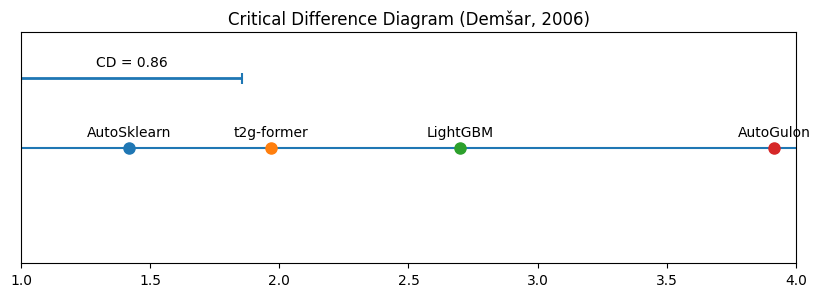

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = train_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

def critical_difference_plot(avg_ranks, names, cd):
    order = np.argsort(avg_ranks)
    avg_ranks = avg_ranks[order]
    names = [names[i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(1, k)
    ax.set_ylim(0, 2)
    ax.set_yticks([])

    ax.hlines(1, 1, k)

    for i, (rank, name) in enumerate(zip(avg_ranks, names)):
        ax.plot(rank, 1, 'o', markersize=8)
        ax.text(rank, 1.1, name, ha='center', fontsize=10)

    ax.hlines(1.6, 1, 1 + cd, linewidth=2)
    ax.vlines(1, 1.55, 1.65)
    ax.vlines(1 + cd, 1.55, 1.65)
    ax.text(1 + cd / 2, 1.7, f"CD = {cd:.2f}", ha='center')

    plt.title("Critical Difference Diagram (Demšar, 2006)", fontsize=12)
    plt.savefig("cd_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


critical_difference_plot(avg_ranks, models, CD)

In [94]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = train_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

stat, p = friedmanchisquare(*[pivot[col] for col in models])
print("Friedman Test")
print("Stat =", stat, "p =", p)

# Nemenyi (matriz completa)
nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi.columns = models
nemenyi.index = models

print("\n=== Nemenyi Matrix ===")
print(nemenyi)

# Holm vs baseline (t2g-former)
baseline = "t2g-former"

ranks = pivot.rank(axis=1, ascending=False)
avg_ranks = ranks.mean()

SE = math.sqrt(k * (k + 1) / (6 * N))

pvals = {}

for model in models:
    if model == baseline:
        continue

    diff = abs(avg_ranks[model] - avg_ranks[baseline])
    z = diff / SE
    pval = 2 * (1 - norm.cdf(abs(z)))
    pvals[model] = pval

sorted_models = sorted(pvals, key=pvals.get)
m = len(sorted_models)

holm_limits = {model: 0.05 / (m - i) for i, model in enumerate(sorted_models)}

holm_df = pd.DataFrame({
    "model": sorted_models,
    "p_value": [pvals[m] for m in sorted_models],
    "holm_limit": [holm_limits[m] for m in sorted_models],
})

holm_df["reject_null"] = holm_df["p_value"] < holm_df["holm_limit"]

print("Holm (baseline =", baseline, ")")
print(holm_df)


Friedman Test
Stat = 63.72727272727276 p = 9.387772675317105e-14

=== Nemenyi Matrix ===
                AutoGulon   AutoSklearn  LightGBM    t2g-former
AutoGulon    1.000000e+00  3.829159e-13  0.001496  2.946254e-08
AutoSklearn  3.829159e-13  1.000000e+00  0.000682  3.505512e-01
LightGBM     1.495625e-03  6.823091e-04  1.000000  1.231855e-01
t2g-former   2.946254e-08  3.505512e-01  0.123185  1.000000e+00
Holm (baseline = t2g-former )
         model       p_value  holm_limit  reject_null
0    AutoGulon  4.915730e-09    0.016667         True
1     LightGBM  2.780690e-02    0.025000        False
2  AutoSklearn  9.894294e-02    0.050000        False


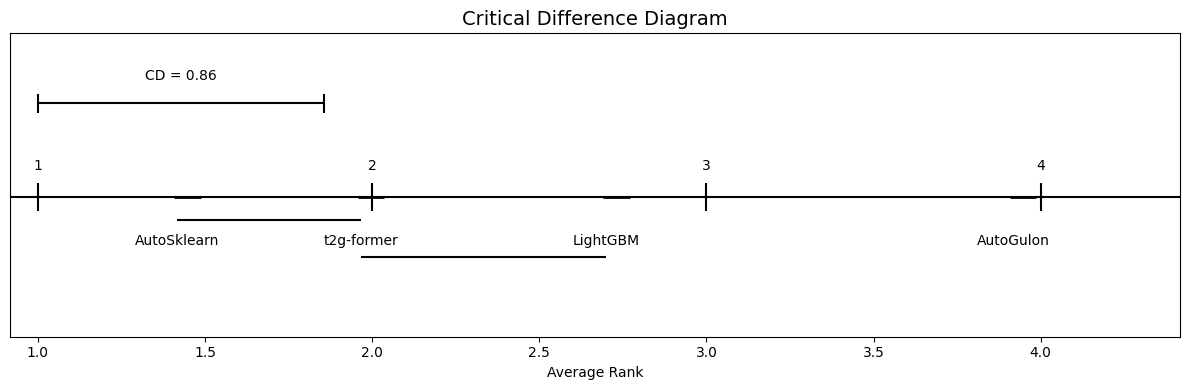

In [95]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cd_demsar(avg_ranks, cd, groups=None, title="Critical Difference Diagram"):
    """
    avg_ranks: dict -> {model: rank}
    cd: float → critical difference
    groups: list of lists → modelos que NÃO são significativamente diferentes
    """
    
    models = list(avg_ranks.keys())
    ranks  = np.array([avg_ranks[m] for m in models])
    
    order = np.argsort(ranks)
    models = [models[i] for i in order]
    ranks  = ranks[order]

    k = len(models)

    fig, ax = plt.subplots(figsize=(12, 4))
    
    ax.hlines(1, ranks.min() - 0.5, ranks.max() + 0.5, color="black")
    
    # Marcações de rank (no topo)
    for r in range(1, k+1):
        ax.text(r, 1.05, str(r), ha="center", va="bottom", fontsize=10)
        ax.vlines(r, 1 - 0.03, 1 + 0.03, color="black")

    ax.hlines(1.20, 1, 1 + cd, color="black")
    ax.vlines(1, 1.18, 1.22, color="black")
    ax.vlines(1 + cd, 1.18, 1.22, color="black")
    ax.text(1 + cd/2, 1.25, f"CD = {cd:.2f}", ha="center")

    for model, r in zip(models, ranks):
        ax.hlines(1, r - 0.01, r + 0.07, color="black", linewidth=2)
        ax.text(r, 0.92, model, ha="center", va="top", fontsize=10)

    if groups:
        y_group = 0.95

        for g in groups:
            idx = [models.index(m) for m in g]
            left  = ranks[idx].min()
            right = ranks[idx].max()
            ax.hlines(y_group, left, right, color="black", linewidth=1.5)
            y_group -= 0.08 

    ax.set_ylim(0.7, 1.35)
    ax.set_xlim(ranks.min() - 0.5, ranks.max() + 0.5)
    ax.set_yticks([])
    ax.set_xlabel("Average Rank")
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 1.416667,
    "t2g-former": 1.966667,
    "LightGBM": 2.700000,
    "AutoGulon": 3.916667
}

cd = 0.8563333333333333

groups = [
    ["AutoSklearn", "t2g-former"],
    ["t2g-former", "LightGBM"],
]

plot_cd_demsar(avg_ranks, cd, groups)

A imagem mostra o **ranking médio** dos quatro modelos testados considerando todos os datasets, além da **Critical Difference (CD = 0.86)** do teste de Nemenyi.

Nessa imagem:
- AutoSklearn aparece como melhor modelo global.
    - Ele aparece com o **menor rank médio**.
    - Em diagramas de CD, **quanto menor o rank melhor o modelo**.
    - **AutoSklearn foi o que apresentou performance mais consistente entre todos os datasets.**

- t2g-former é o segundo melhor.
    - Tem rank médio **2.0**, próximo do AutoSklearn.
    - A diferença entre AutoSklearn e t2g-former é **menor do que a CD**, portanto **não é estatisticamente significativa**.
    - Isso quer dizer:
        - Ambos têm desempenhos semelhantes.
        - Não podemos afirmar que AutoSklearn supera t2g-former com 95% de confiança.

- LightGBM aparece em terceiro lugar
    - Está **estatisticamente pior que AutoSklearn**.
    - Pode estar **ligeiramente pior que t2g-former**, dependendo dos ranks exatos — mas na imagem ele aparenta estar **fora do intervalo significativo**.

- AutoGluon é o pior modelo de todos**

Rank médio **≈ 3.9**, bem distante dos demais.


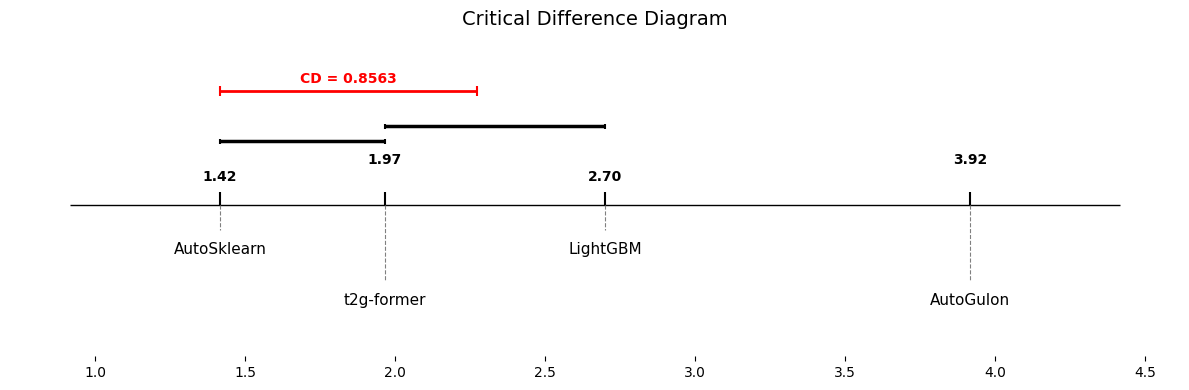

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

def plot_cd_diagram_adjusted(avg_ranks, cd, title="Critical Difference Diagram"):
    """
    Gera o diagrama de CD com ajuste automático de sobreposição de texto
    usando escalonamento vertical alternado.
    """

    sorted_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])
    models = [item[0] for item in sorted_ranks]
    ranks = np.array([item[1] for item in sorted_ranks])
    k = len(models)

    groups = []

    for i in range(k):
        for j in range(k-1, i, -1):
            if ranks[j] - ranks[i] < cd:
                groups.append((i, j))

                break

    # Filtrar subgrupos redundantes
    final_groups = []

    for g1 in groups:
        is_subgroup = False

        for g2 in groups:
            if g1 != g2 and g1[0] >= g2[0] and g1[1] <= g2[1]:
                is_subgroup = True
                break

        if not is_subgroup:
            final_groups.append(g1)
            
    fig, ax = plt.subplots(figsize=(12, 4))
    
    x_min = ranks.min()
    x_max = ranks.max()
    
    ax.set_xlim(x_min - 0.7, x_max + 0.7)
    ax.set_ylim(0.0, 1.2)
    
    main_line_y = 0.6
    
    ax.hlines(main_line_y, x_min - 0.5, x_max + 0.5, color="black", linewidth=1)
    
    
    for i, (model, r) in enumerate(zip(models, ranks)):
        ax.vlines(r, main_line_y, main_line_y + 0.05, color="black")
        
        rank_text_y = main_line_y + 0.08 if i % 2 == 0 else main_line_y + 0.15
        
        ax.text(r, rank_text_y, f"{r:.2f}", ha="center", va="bottom", fontsize=10, fontweight='bold')
        
        if i % 2 == 0:
            model_text_y = main_line_y - 0.15
            connector_y = model_text_y + 0.05
        else:
            model_text_y = main_line_y - 0.35
            connector_y = model_text_y + 0.05

        ax.plot([r, r], [main_line_y, connector_y], color="gray", linestyle="--", linewidth=0.8)
        ax.text(r, model_text_y, model, ha="center", va="top", fontsize=11)


    cd_y_pos = 1.05
    ax.hlines(cd_y_pos, x_min, x_min + cd, color="red", linewidth=2)
    ax.vlines(x_min, cd_y_pos - 0.02, cd_y_pos + 0.02, color="red")
    ax.vlines(x_min + cd, cd_y_pos - 0.02, cd_y_pos + 0.02, color="red")
    ax.text(x_min + cd/2, cd_y_pos + 0.03, f"CD = {cd:.4f}", ha="center", color="red", fontweight='bold')


    base_group_y = main_line_y + 0.25
    step_y = 0.06
    
    final_groups.sort(key=lambda x: x[1]-x[0]) 
    occupied_levels = [] 

    for start_idx, end_idx in final_groups:
        left_val = ranks[start_idx]
        right_val = ranks[end_idx]
        
        level = 0

        while True:
            collision = False

            for (occ_left, occ_right, occ_level) in occupied_levels:
                if occ_level == level:
                    if not (right_val < occ_left - 0.05 or left_val > occ_right + 0.05):
                        collision = True
                        break

            if not collision:
                break

            level += 1
        
        occupied_levels.append((left_val, right_val, level))
        
        y_pos = base_group_y + level * step_y
        ax.hlines(y_pos, left_val, right_val, color="black", linewidth=2.5)
        ax.vlines(left_val, y_pos - 0.01, y_pos + 0.01, color="black")
        ax.vlines(right_val, y_pos - 0.01, y_pos + 0.01, color="black")

    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title(title, fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 1.416667,
    "t2g-former": 1.966667,
    "LightGBM": 2.700000,
    "AutoGulon": 3.916667
}

cd = 0.856333

plot_cd_diagram_adjusted(avg_ranks, cd)

### extra plots

In [97]:
df = train_results

metrics = ["auc_ovo", "mean_acc", "g_mean", "mean_cross_entropy"]

results = {}
for m in metrics:
    results[m] = df[df["split"]=="train"].groupby("nome_modelo")[m].mean().sort_values(ascending=False)

pd.DataFrame(results)


,auc_ovo,mean_acc,g_mean,mean_cross_entropy
nome_modelo,,,,
AutoGulon,0.838251,0.745067,0.404518,0.812158
AutoSklearn,0.944774,0.914652,0.842496,0.478615
LightGBM,0.889410,0.837479,0.755742,0.585106
t2g-former,0.929302,0.871490,0.797996,0.292221


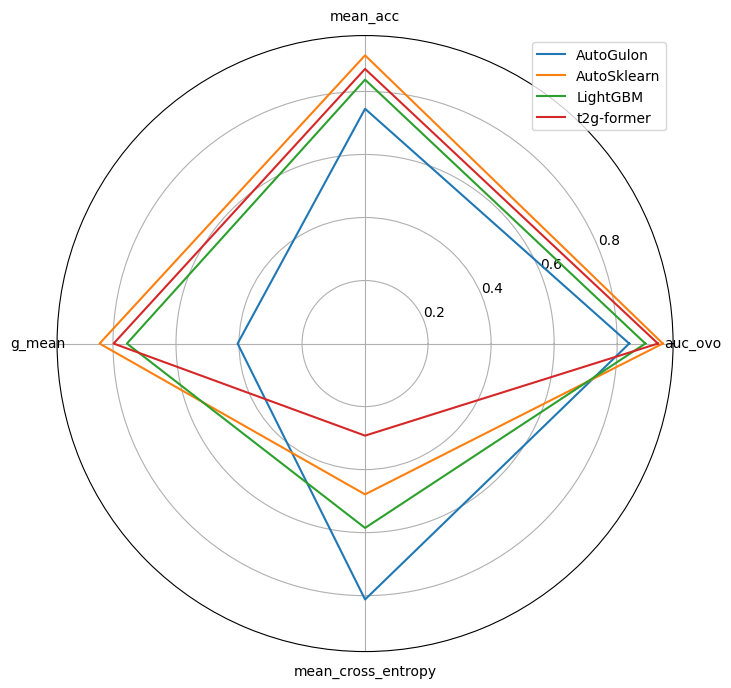

In [99]:
import matplotlib.pyplot as plt
import numpy as np

df = train_results
test = df[df["split"]=="train"].groupby("nome_modelo").mean(numeric_only=True)

metrics = ["auc_ovo","mean_acc","g_mean","mean_cross_entropy"]
labels = metrics

values = test[metrics].values.tolist()
names = test.index.tolist()

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i, name in enumerate(names):
    v = values[i]
    v = np.concatenate((v,[v[0]]))
    ax.plot(angles, v, label=name)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend()
plt.show()

<Axes: xlabel='tempo_total', ylabel='g_mean'>

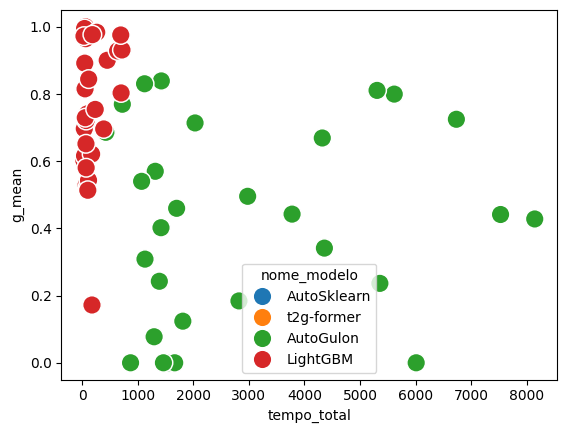

In [101]:
import seaborn as sns

test["tempo_total"] = test["tempo_tune"] + test["tempo_train"] + test["tempo_predict"]

sns.scatterplot(data=test, x="tempo_total", y="g_mean", hue="nome_modelo", s=180)

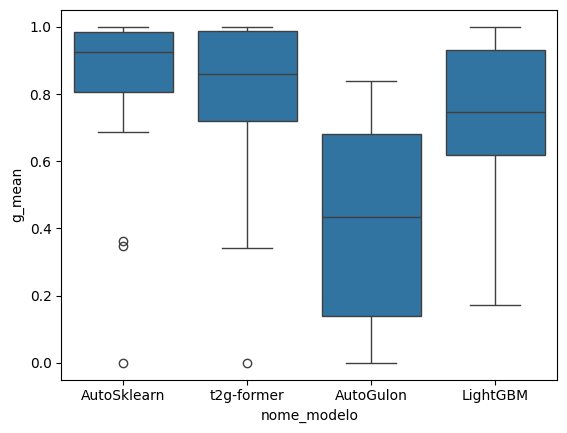

In [102]:
sns.boxplot(data=df[df["split"]=="train"], x="nome_modelo", y="g_mean")
plt.show()

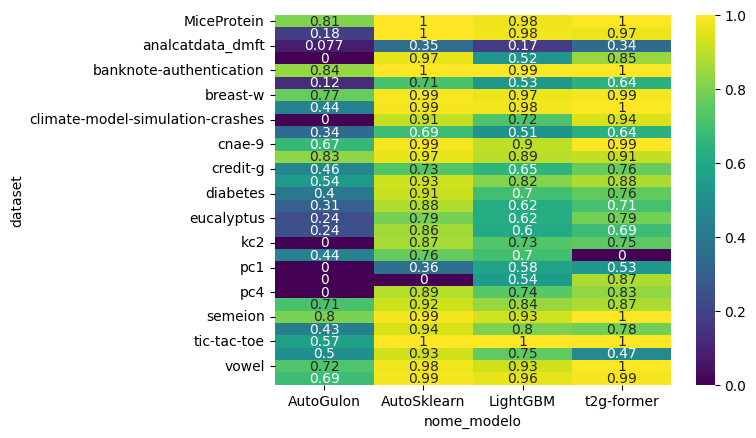

In [103]:
pivot = df[df["split"]=="train"].pivot(index="dataset", columns="nome_modelo", values="g_mean")

sns.heatmap(pivot, annot=True, cmap="viridis")
plt.show()

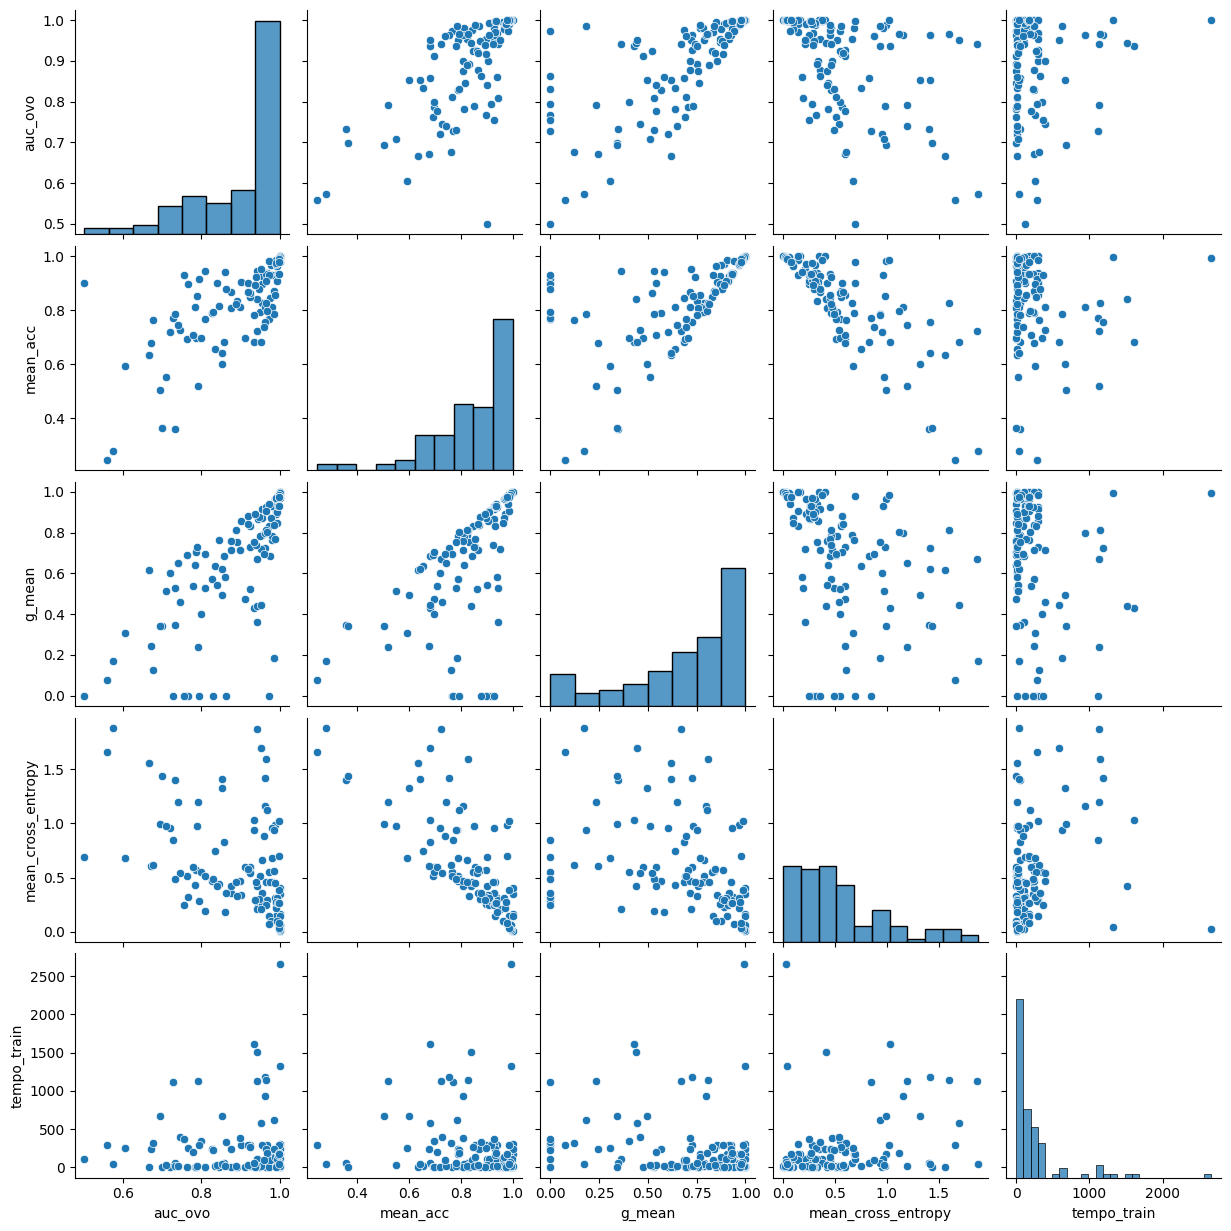

In [104]:
test = df[df["split"]=="train"]

sns.pairplot(test[["auc_ovo","mean_acc","g_mean","mean_cross_entropy","tempo_train"]])
plt.show()

# statistics for train datasets

In [105]:
results_path = "results.csv"
results = pd.read_csv(results_path)

test_results = results[results["split"] == "test"]
test_results.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
5,test,AutoSklearn,wdbc,NaN,54.669093,0.998089,0.988304,0.983999,0.079230,0.406010
7,test,AutoSklearn,pc4,NaN,115.232249,0.927329,0.897260,0.577596,0.310648,3.910934
9,test,AutoSklearn,credit-g,NaN,294.931927,0.772701,0.733333,0.488094,0.627840,0.322403


Estamos testando:
- H₀ (hipótese nula): todos os modelos têm desempenho equivalente.
    - Ou seja: as diferenças nos ranks médios são apenas devido ao acaso.

- H₁ (hipótese alternativa): pelo menos um modelo tem desempenho sistematicamente diferente.

In [117]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, rankdata
from math import sqrt
from itertools import combinations
from scipy.stats import norm

df_avg = test_results.groupby(["dataset", "nome_modelo"])["g_mean"].mean().reset_index()

table = df_avg.pivot(index="dataset", columns="nome_modelo", values="g_mean")
table = table.dropna()

models = list(table.columns)
datasets = list(table.index)
k = len(models)
N = len(datasets)

print(f"Comparando {k} modelos e {N} datasets")

Comparando 4 modelos e 30 datasets


In [118]:
# 2. CALCULAR RANKS POR DATASET

ranks = table.rank(axis=1, ascending=False)  # maior g-mean = melhor rank (1)
avg_ranks = ranks.mean()

print("Average Ranks")
print(avg_ranks)

Average Ranks
nome_modelo
AutoGulon      3.700000
AutoSklearn    2.050000
LightGBM       2.166667
t2g-former     2.083333
dtype: float64


O que foi feito: 

- Ordenado os modelos pela métrica G-Mean
- O melhor modelo no dataset recebe rank 1, o segundo melhor rank 2, e assim por diante
- Depois, é calculada a média desses ranks de cada modelo ao longo de todos os datasets.

Ou seja, os número exibidos são as médias dos ranks.

**Detalhe**:
Quanto MENOR o rank médio, melhor o modelo.
- Rank médio 1.0 → o modelo foi sempre o melhor em todos os datasets.
- Rank médio perto de k → o modelo foi quase sempre o pior.

Interpretando os seus resultados:

1. AutoSklearn – 2.05
    - Fica em média perto de 2o lugar.
    - É o melhor modelo globalmente, segundo o critério de G-Mean.

2. t2g-former – 2.08
    - Fica em média perto de 2o lugar.
    - Costuma performar bem, logo atrás do AutoSklearn.

3. LightGBM – 2.166667
    - Em média entre 2o e 3o lugar.
    - Muito próximos dos outros 2 melhores modelos

4. AutoGluon – 3.7
    - Quase k, ou seja, em muitos datasets ele foi o pior dos quatro.

In [119]:
# 3. FRIEDMAN TEST

stats = [ranks[col].values for col in models]
friedman_stat, friedman_p = friedmanchisquare(*stats)

print("\n===== Friedman Test =====")
print(f"Statistic: {friedman_stat:.4f}")
print(f"P-value: {friedman_p:.4f}")


===== Friedman Test =====
Statistic: 35.0404
P-value: 0.0000


**ISSO AQUI VAI MUDAR QUANDO CHEGAREM OS NOVOS MODELOS**

Esse valor do Friedman mede quão diferentes os ranks são.

Para 4 modelos (k = 4), valores abaixo de ~8–9 tenderiam a não rejeitar H₀.

Mas 57.47 é gigante, ou seja:
- Os modelos têm ranks extremamente diferentes entre si.

Sobre o p-value:
- O p-value NÃO é exatamente zero, mas é um número muito pequeno e o Python arredondou para 0.
- Isso significa que as chances das diferenças observadas serem aleatórias são praticamente nulas.

Interpretação dos resultados:
- p-value pequeno (< 0.000001)
- Valor estatístico alto (57.47)
- Então:
    - REJEITA a hipótese nula.
    - Portanto:
        - Os classificadores NÃO têm desempenho equivalente. Existem diferenças estatisticamente significativas entre eles.

In [120]:
# 4. NEMENYI POST-HOC

q_alpha = 2.569   # para k=4 e alfa=0.05 (Tabela 5a)
CD = q_alpha * sqrt(k*(k+1)/(6*30))

print("Nemenyi Critical Difference")
print(f"CD = {CD}")

nemenyi_results = {}

for m1, m2 in combinations(models, 2):
    diff = abs(avg_ranks[m1] - avg_ranks[m2])
    nemenyi_results[(m1, m2)] = diff > CD

print("Nemenyi Significant Pairs (p<0.05)")

for (m1, m2), sig in nemenyi_results.items():
    if sig:
        print(f"{m1} vs {m2} → SIGNIFICANTE")


Nemenyi Critical Difference
CD = 0.8563333333333333
Nemenyi Significant Pairs (p<0.05)
AutoGulon vs AutoSklearn → SIGNIFICANTE
AutoGulon vs LightGBM → SIGNIFICANTE
AutoGulon vs t2g-former → SIGNIFICANTE


In [110]:
models

['AutoGulon', 'AutoSklearn', 'LightGBM', 't2g-former']

In [111]:
# 5. HOLM POST-HOC (controle)

baseline = models[-1]
print(f"Baseline: {baseline}")

# estatística z = (Ri - Rj) / SE
SE = sqrt(k*(k+1)/(6*30))

holm_raw = {}

for m in models:
    if m == baseline:
        continue

    z = abs(avg_ranks[m] - avg_ranks[baseline]) / SE
    p = 2*(1 - norm.cdf(z))
    holm_raw[m] = p

# ordenar p-values
sorted_holm = sorted(holm_raw.items(), key=lambda x: x[1])

print("Holm Post-Hoc")

for i, (model, p) in enumerate(sorted_holm, start=1):
    threshold = 0.05 / (k - i)
    decision = "REJEITA" if p < threshold else "NÃO REJEITA"

    print(f"{model:20s} p={p:.6f}  lim={threshold:.6f} → {decision}")

Baseline: t2g-former
Holm Post-Hoc
AutoGulon            p=0.000001  lim=0.016667 → REJEITA
LightGBM             p=0.802587  lim=0.025000 → NÃO REJEITA
AutoSklearn          p=0.920344  lim=0.050000 → NÃO REJEITA


O que é o Holm Post-Hoc?
- Depois que o teste de Friedman detecta que há diferenças significativas entre os modelos, o teste de Holm serve para comparar um modelo de referência (baseline) com todos os outros, controlando FWER (Family-wise Error Rate).

Em suma, o Holm testa se um modelo é estatisticamente diferente do baseline.

Para cada par:
- p-value vem das diferenças dos ranks entre cada modelo e o baseline lmite é o limiar ajustado de Holm
- Se p <= limite → rejeita H₀ → diferença significativa
- Se p > limite → não rejeita → não há diferença significativa

Resumo geral (Friedman + Nemenyi + Holm)
- AutoGluon
    - Estatisticamente pior que todos os outros em ambos testes.
    - Deve ser considerado inferior.

- AutoSklearn
    - Melhor rank médio
    - Superior a LightGBM pelo teste de Nemenyi
    - Mas não superior ao t2g-former no teste de Holm

- t2g-former
    - Estatisticamente equivalente ao AutoSklearn
    - Estatisticamente equivalente ao LightGBM
    - Muito melhor que AutoGluon

- LightGBM
    - Inferior ao AutoSklearn (Nemenyi detectou essa diferença)
    - Mas equivalente ao t2g-former no Holm
    - Desempenho intermediário.

In [113]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = test_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

stat, p = friedmanchisquare(*[pivot[col] for col in models])
print("Friedman Test")
print("Stat =", stat, "p =", p)

# Nemenyi (matriz completa)
nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi.columns = models
nemenyi.index = models

print("\n=== Nemenyi Matrix ===")
print(nemenyi)

# Holm vs baseline (t2g-former)
baseline = "t2g-former"

ranks = pivot.rank(axis=1, ascending=False)
avg_ranks = ranks.mean()

SE = math.sqrt(k * (k + 1) / (6 * N))

pvals = {}

for model in models:
    if model == baseline:
        continue

    diff = abs(avg_ranks[model] - avg_ranks[baseline])
    z = diff / SE
    pval = 2 * (1 - norm.cdf(abs(z)))
    pvals[model] = pval

sorted_models = sorted(pvals, key=pvals.get)
m = len(sorted_models)

holm_limits = {model: 0.05 / (m - i) for i, model in enumerate(sorted_models)}

holm_df = pd.DataFrame({
    "model": sorted_models,
    "p_value": [pvals[m] for m in sorted_models],
    "holm_limit": [holm_limits[m] for m in sorted_models],
})

holm_df["reject_null"] = holm_df["p_value"] < holm_df["holm_limit"]

print("Holm (baseline =", baseline, ")")
print(holm_df)


Friedman Test
Stat = 35.04040404040404 p = 1.1945380955887043e-07

=== Nemenyi Matrix ===
             AutoGulon  AutoSklearn  LightGBM  t2g-former
AutoGulon     1.000000     0.000004  0.000025    0.000007
AutoSklearn   0.000004     1.000000  0.985288    0.999642
LightGBM      0.000025     0.985288  1.000000    0.994518
t2g-former    0.000007     0.999642  0.994518    1.000000
Holm (baseline = t2g-former )
         model   p_value  holm_limit  reject_null
0    AutoGulon  0.000001    0.016667         True
1     LightGBM  0.802587    0.025000        False
2  AutoSklearn  0.920344    0.050000        False


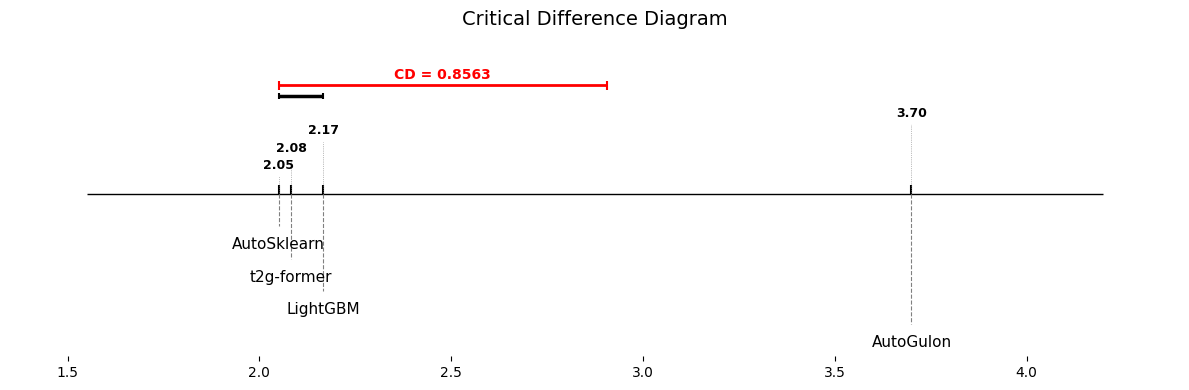

In [125]:
def plot_cd_diagram_robust(avg_ranks, cd, title="Critical Difference Diagram"):
    sorted_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])
    models = [item[0] for item in sorted_ranks]
    ranks = np.array([item[1] for item in sorted_ranks])
    k = len(models)

    groups = []

    for i in range(k):
        for j in range(k-1, i, -1):
            if ranks[j] - ranks[i] < cd:
                groups.append((i, j))
                break
    
    final_groups = []

    for g1 in groups:
        is_subgroup = False

        for g2 in groups:
            if g1 != g2 and g1[0] >= g2[0] and g1[1] <= g2[1]:
                is_subgroup = True
                break

        if not is_subgroup:
            final_groups.append(g1)
            
    fig, ax = plt.subplots(figsize=(12, 4)) 
    
    x_min = ranks.min()
    x_max = ranks.max()
    ax.set_xlim(x_min - 0.7, x_max + 0.7)
    ax.set_ylim(0.0, 1.4)
    
    main_line_y = 0.75 
    
    ax.hlines(main_line_y, x_min - 0.5, x_max + 0.5, color="black", linewidth=1)
    
    text_levels = [0.2, 0.35, 0.50, 0.65]
    rank_levels = [0.1, 0.18, 0.26, 0.34]
    
    for i, (model, r) in enumerate(zip(models, ranks)):
        lvl_idx = i % 4 
        
        ax.vlines(r, main_line_y, main_line_y + 0.04, color="black")
        
        rank_y = main_line_y + rank_levels[lvl_idx]
        ax.text(r, rank_y, f"{r:.2f}", ha="center", va="bottom", fontsize=9, fontweight='bold')
        ax.plot([r, r], [main_line_y, rank_y - 0.02], color="gray", linestyle=":", linewidth=0.5)
        
        model_y = main_line_y - text_levels[lvl_idx]
        ax.text(r, model_y, model, ha="center", va="top", fontsize=11)
        ax.plot([r, r], [main_line_y, model_y + 0.05], color="gray", linestyle="--", linewidth=0.8)


    cd_y = 1.25
    ax.hlines(cd_y, x_min, x_min + cd, color="red", linewidth=2)
    ax.vlines(x_min, cd_y - 0.02, cd_y + 0.02, color="red")
    ax.vlines(x_min + cd, cd_y - 0.02, cd_y + 0.02, color="red")
    ax.text(x_min + cd/2, cd_y + 0.03, f"CD = {cd:.4f}", ha="center", color="red", fontweight='bold')

    base_group_y = main_line_y + 0.45 
    step_y = 0.08
    
    final_groups.sort(key=lambda x: x[1]-x[0]) 
    occupied_levels = [] 

    for start_idx, end_idx in final_groups:
        left_val = ranks[start_idx]
        right_val = ranks[end_idx]
        
        level = 0

        while True:
            collision = False

            for (occ_left, occ_right, occ_level) in occupied_levels:
                if occ_level == level:
                    if not (right_val < occ_left - 0.05 or left_val > occ_right + 0.05):
                        collision = True
                        break

            if not collision:
                break

            level += 1
        
        occupied_levels.append((left_val, right_val, level))
        
        y_pos = base_group_y + level * step_y
        ax.hlines(y_pos, left_val, right_val, color="black", linewidth=2.5)
        ax.vlines(left_val, y_pos - 0.015, y_pos + 0.015, color="black")
        ax.vlines(right_val, y_pos - 0.015, y_pos + 0.015, color="black")

    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title(title, fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 2.050000,
    "t2g-former": 2.083333,
    "LightGBM": 2.166667,
    "AutoGulon": 3.700000
}

cd = 0.8563
plot_cd_diagram_robust(avg_ranks, cd)